## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

###  Load Dataset

In [2]:
df = pd.read_csv('student_dataset_dirty.csv')
df

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
0,101,Rahul,20.0,Male,85.0,CSE,12/01/2020
1,102,Sneha,21.0,Female,90.0,IT,15-02-2021
2,103,Amit,NaN,M,78.0,ECE,2022/03/10
3,104,Priya,19.0,F,NaN,cse,01-04-2020
4,105,Kiran,22.0,NaN,88.0,IT,2021/05/20
5,106,Anjali,200.0,Female,95.0,ECE,13/06/2019
6,107,Ravi,21.0,male,300.0,CSE,07-07-2022
7,108,Pooja,NaN,F,76.0,IT,2020/08/15
8,109,Vikram,20.0,Male,84.0,ECE,09-09-2021
9,110,Neha,19.0,Female,NaN,CSE,10/10/2020


### Perform Basic Checks

In [3]:
df.head()

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
0,101,Rahul,20.0,Male,85.0,CSE,12/01/2020
1,102,Sneha,21.0,Female,90.0,IT,15-02-2021
2,103,Amit,NaN,M,78.0,ECE,2022/03/10
3,104,Priya,19.0,F,NaN,cse,01-04-2020
4,105,Kiran,22.0,NaN,88.0,IT,2021/05/20


In [4]:
df.tail()

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
25,126,Keerthi,NaN,Female,88.0,IT,2022/02/14
26,127,Naresh,21.0,M,79.0,ECE,27/03/2020
27,128,Bhavana,20.0,Male,95.0,CSE,28-04-2019
28,129,Tarun,19.0,F,60.0,IT,2021/05/30
29,130,Sindhu,300.0,female,105.0,ECE,31-02-2020


In [5]:
df.sample()

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
25,126,Keerthi,NaN,Female,88.0,IT,2022/02/14


In [6]:
print("Size:",df.size)

Size: 210


In [7]:
print("Shape:", df.shape)

Shape: (30, 7)


In [8]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  30 non-null     int64  
 1   Name        30 non-null     object 
 2   Age         25 non-null     float64
 3   Gender      27 non-null     object 
 4   Marks       26 non-null     float64
 5   Department  30 non-null     object 
 6   Join_Date   30 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ KB
None


In [9]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Student_ID         Age       Marks
count   30.000000   25.000000   26.000000
mean   115.500000   38.640000   91.230769
std      8.803408   65.241142   43.829038
min    101.000000   18.000000   60.000000
25%    108.250000   19.000000   77.250000
50%    115.500000   20.000000   85.000000
75%    122.750000   21.000000   90.000000
max    130.000000  300.000000  300.000000


In [10]:
df.columns.tolist()

['Student_ID', 'Name', 'Age', 'Gender', 'Marks', 'Department', 'Join_Date']

## DATA CLEANING

### Column Standardization

- I found inconsistent values in the Gender column, such as "Male", "male", "M", "Female", "female", and "F". 
- To make the data consistent and easier to analyze, I converted them into standard categories: Male and Female.

#### Checking Unique Values in Categorical Columns
- I checked the unique values in the categorical columns. 
- This helped me identify inconsistent entries such as different spellings, abbreviations,
- and letter cases representing the same category
- I used a loop to display the unique values for all categorical columns at once.

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


Name
['Rahul' 'Sneha' 'Amit' 'Priya' 'Kiran' 'Anjali' 'Ravi' 'Pooja' 'Vikram'
 'Neha' 'Arjun' 'Meena' 'Suresh' 'Kavya' 'Rohit' 'Divya' 'Manoj' 'Nisha'
 'Ajay' 'Swathi' 'Raj' 'Deepa' 'Karthik' 'Lavanya' 'Varun' 'Keerthi'
 'Naresh' 'Bhavana' 'Tarun' 'Sindhu']

Gender
['Male' 'Female' 'M' 'F' nan 'male' 'female']

Department
['CSE' 'IT' 'ECE' 'cse']

Join_Date
['12/01/2020' '15-02-2021' '2022/03/10' '01-04-2020' '2021/05/20'
 '13/06/2019' '07-07-2022' '2020/08/15' '09-09-2021' '10/10/2020'
 '11-11-2019' '2022/12/01' '13/01/2020' '14-02-2021' '2021/03/15'
 '16/04/2020' '17-05-2019' '2022/06/20' '19/07/2021' '20-08-2020'
 '21/09/2019' '22-10-2022' '2021/11/11' '24/12/2020' '25-01-2021'
 '2022/02/14' '27/03/2020' '28-04-2019' '2021/05/30' '31-02-2020']


#### Handling Inconsistent Values in Gender Column
- After checking the unique values in the Gender column
  
- I found that the same categories were represented in different formats,
- such as "Male", "male", "M", "Female", "female", and "F". 
- To make the data consistent and easier to analyze, 
- I standardized these values into two categories: Male and Female.

In [12]:
df['Gender'] = df['Gender'].replace({'M': 'Male',
    'male': 'Male',
    'F': 'Female',
    'female': 'Female'
})

In [13]:
df['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

### Standardizing Department Column

In [14]:
df['Department'].unique()

array(['CSE', 'IT', 'ECE', 'cse'], dtype=object)

- After checking the unique values in the Department column, 
- I found inconsistent formatting such as "CSE" and "cse". 
- Since both represent the same department,
- I standardized the values to maintain consistency and improve data quality.

In [15]:
df['Department'] = df['Department'].str.upper()

In [16]:
print(df['Department'].unique())

['CSE' 'IT' 'ECE']


### 🧹 STEP 2: Check Duplicates (BEFORE missing values)
#### ✅ Why first?

- Because duplicates can:

  * distort mean/median
  * give wrong insights

### Check Duplicate values  

##### To Check Duplicates Rows for The All columns 
- df[df.duplicated()] returns rows where all column values are exactly the same as a previous row (i.e., full row duplicates), excluding the first occurrence.

In [17]:
df[df.duplicated()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


In [18]:
df.duplicated().sum()

np.int64(0)

#### Observation :- No duplicate values were found in the Entire dataset.

#### duplicated():- only detects exact row matches, so it misses partial duplicates (like same Name but different Age). 
##### To handle such cases,
-  we perform column-wise duplicate detection using the subset parameter in Pandas.


#### Column-Wise Duplicate Detection

##### Before proceeding with duplicate removal, a professional approach is to focus only on important (business-critical) columns rather than checking the entire dataset blindly.
-  Before proceeding with duplicate removal, I first analyze my dataset
     * columns: Student_ID, Name, Age, Gender, Marks, Department, Join_Date.
- In this Dataset, 
     * I treat Student_ID as the primary unique column
     *  Because each student should have a unique ID.
     *  Columns like Name, Age, or Department can repeat and are not reliable for identifying duplicates.

So, instead of checking full-row duplicates, I focus on Student_ID to detect logical duplicates.

In [19]:
df[df.duplicated(subset='Student_ID')]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


#### Observation :- No duplicates were found in the Student_ID column, confirming that each record is unique.

#### Multiple Column Check

In [20]:
df[df.duplicated(subset=['Student_ID', 'Name'])]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


#### Observation :- 
- #####   No duplicate records were found based on the combination of Student_ID and Name.
- #####   This indicates that each student entry is Unique when considering both fields together.

 ### Handling Duplicate Values 

##### Case 1: No Duplicates Found 
-  After checking for duplicate values,
   * I found that this dataset does not contain any duplicate records, so no direct removal was required. 
   *  Still, I consider this step important because it confirms that the data is clean and each entry is unique before moving further.

##### Case 2: If Duplicates Were Present
- If duplicates had been present,
   * I would have handled them carefully instead of removing them blindly. For exact duplicate rows, I would remove them directly
   * But,for partial duplicates (like same Student_ID with different values)
   * I would first analyze the data and then decide whether to keep the latest,record the first record, or apply some rule based on the context.

#### 1. Identify Duplicate Rows

In [21]:
df[df.duplicated()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


#### 2. Check Column-Wise Duplicates (Important Columns)

In [22]:
df[df.duplicated(subset='Student_ID')]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


#### 3. Remove Duplicate Records
-  Remove full row duplicates:

In [23]:
df = df.drop_duplicates()

- Remove duplicates based on key column:

In [24]:
df = df.drop_duplicates(subset='Student_ID')

##### Finally, I would recheck the dataset to make sure all duplicates are handled properly.

In [25]:
df.duplicated().sum()

np.int64(0)

### 🎯 Key Insight

#### Duplicate handling should always be based on business logic and important columns (like Student_ID) rather than blindly removing rows.
#### This ensures accurate and meaningful data cleaning.

#### 👉 This structured approach demonstrates a professional workflow for handling duplicates in real-world data analysis projects.

In [26]:
df.Student_ID.unique()

array([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130])

### Check Missing Values

In [27]:
df.isnull().sum().sort_values(ascending=False)

Age           5
Marks         4
Gender        3
Student_ID    0
Name          0
Department    0
Join_Date     0
dtype: int64

In [28]:
df['Age'].value_counts()

Age
20.0     6
21.0     6
19.0     5
22.0     3
18.0     2
200.0    1
23.0     1
300.0    1
Name: count, dtype: int64

In [29]:
df['Age'].unique() 

array([ 20.,  21.,  nan,  19.,  22., 200.,  18.,  23., 300.])

In [30]:
df.loc[df['Age'].isnull()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
2,103,Amit,NaN,Male,78.0,ECE,2022/03/10
7,108,Pooja,NaN,Female,76.0,IT,2020/08/15
12,113,Suresh,NaN,Male,65.0,CSE,13/01/2020
18,119,Ajay,NaN,Female,77.0,CSE,19/07/2021
25,126,Keerthi,NaN,Female,88.0,IT,2022/02/14


#### Step 1: Check Distribution

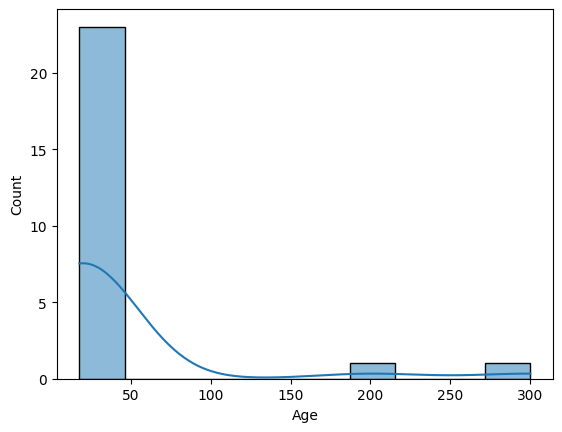

In [31]:
sns.histplot(x='Age',data=df,kde=True)
plt.show()

<Axes: xlabel='Age'>

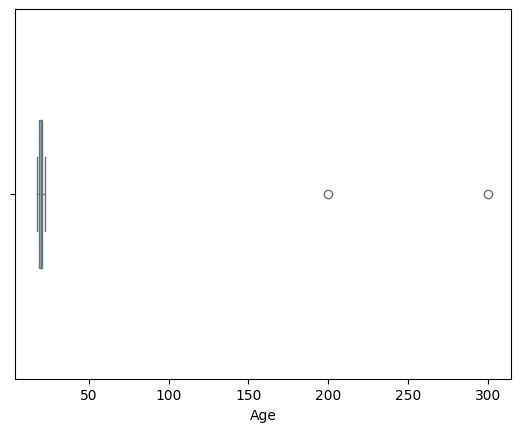

In [32]:
sns.boxplot(x='Age',data=df,width=0.4,color='skyblue')

- Since the column contains extreme values (200 and 300), the distribution becomes skewed.

### Handling Missing values by mean() or median() ?
#### Step 2: Mean vs Median

#### Mean()

    df['Age'].mean()

    Mean gets affected by 200 and 300.

* Example:

      20, 21, 22, 19, 200

      Mean = 56.4

      56.4 is not a realistic student age.
  
#### Median ()

    df['Age'].median()

- Median takes the middle value and is not affected much by outliers.

- Example:

      19, 20, 21, 22, 200

      Median = 21

      21 is reasonable.


      Since the Age column contains outliers,

       I chose the MEDIAN() to fill the missing values because  " the median is less affected by extreme values compared to the mean ".

  
  

In [33]:
df['Age'] =df['Age'].fillna(df['Age'].median())

In [34]:
df.loc[df['Age'].isnull()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


##### Handling Missing Values in Marks Column

In [35]:
df.isnull().sum().sort_values(ascending=False)

Marks         4
Gender        3
Student_ID    0
Name          0
Age           0
Department    0
Join_Date     0
dtype: int64

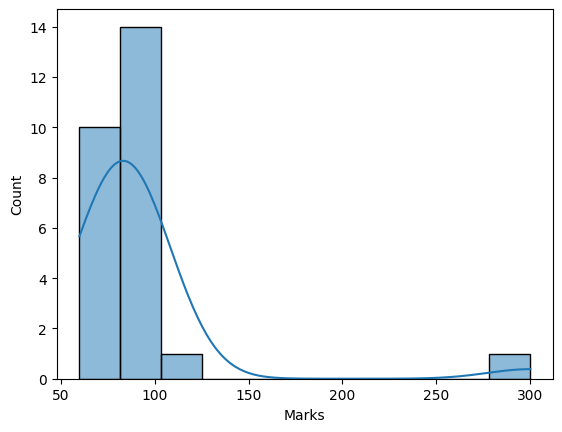

In [36]:
sns.histplot(x='Marks',data=df,kde=True)
plt.show()

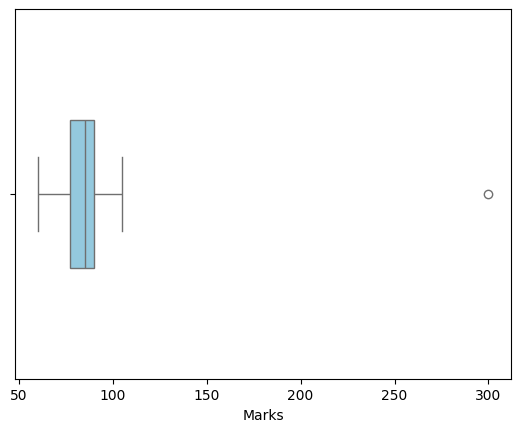

In [37]:
sns.boxplot(x='Marks',data=df,width=0.4,color='skyblue')
plt.show()

In [38]:
df.Marks.value_counts()

Marks
85.0     3
88.0     2
95.0     2
90.0     2
89.0     1
60.0     1
79.0     1
80.0     1
72.0     1
66.0     1
77.0     1
92.0     1
65.0     1
70.0     1
87.0     1
91.0     1
84.0     1
76.0     1
300.0    1
78.0     1
105.0    1
Name: count, dtype: int64

In [39]:
df.loc[df['Marks'].isnull()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
3,104,Priya,19.0,Female,NaN,CSE,01-04-2020
9,110,Neha,19.0,Female,NaN,CSE,10/10/2020
17,118,Nisha,21.0,Female,NaN,ECE,2022/06/20
24,125,Varun,18.0,Female,NaN,CSE,25-01-2021


##### The Marks column contains missing values and extreme values (outliers).

- since outliers can significantly affect the mean, I used the median to replace the missing values


In [40]:
df['Marks'] = df['Marks'].fillna(df['Marks'].median()) 

In [41]:
df.loc[df['Marks'].isnull()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date


In [42]:
df.isnull().sum().sort_values(ascending=False)

Gender        3
Student_ID    0
Name          0
Age           0
Marks         0
Department    0
Join_Date     0
dtype: int64

##### Handling Missing values in Gender Column

In [43]:
df.isnull().sum().sort_values(ascending=False)

Gender        3
Student_ID    0
Name          0
Age           0
Marks         0
Department    0
Join_Date     0
dtype: int64

In [44]:
df.Gender.value_counts()


Gender
Female    14
Male      13
Name: count, dtype: int64

- The Gender column contains missing values and is a categorical column. 
- Since categorical data cannot be filled using mean or median,
- I used the mode (most frequent value) to replace the missing values. 

In [45]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [46]:
print('Missing Count: ',df['Gender'].isnull().sum())

Missing Count:  0


######
- After cleaning the missing values and standardizing the categorical columns,
- I checked the Join_Date column.
- I found that the dates were stored in different formats
- such as DD/MM/YYYY, DD-MM-YYYY, and YYYY/MM/DD. 
       
- To make the data consistent and easier to analyze, I converted the Join_Date column into a standard datetime format.

#### Handling Date Format Issues

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  30 non-null     int64  
 1   Name        30 non-null     object 
 2   Age         30 non-null     float64
 3   Gender      30 non-null     object 
 4   Marks       30 non-null     float64
 5   Department  30 non-null     object 
 6   Join_Date   30 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ KB


- Join_Date is in Object we need to convert in to Datetime

In [48]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'],format='mixed',dayfirst=True,errors='coerce')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Student_ID  30 non-null     int64         
 1   Name        30 non-null     object        
 2   Age         30 non-null     float64       
 3   Gender      30 non-null     object        
 4   Marks       30 non-null     float64       
 5   Department  30 non-null     object        
 6   Join_Date   29 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 1.8+ KB


- After Conversion object in to datetime
- Data type changed from object to datetime64[ns].
- Only 1 date became NaT.
- That invalid date is 31-02-2020.

In [50]:
df['Join_Date'].unique()

<DatetimeArray>
['2020-01-12 00:00:00', '2021-02-15 00:00:00', '2022-03-10 00:00:00',
 '2020-04-01 00:00:00', '2021-05-20 00:00:00', '2019-06-13 00:00:00',
 '2022-07-07 00:00:00', '2020-08-15 00:00:00', '2021-09-09 00:00:00',
 '2020-10-10 00:00:00', '2019-11-11 00:00:00', '2022-12-01 00:00:00',
 '2020-01-13 00:00:00', '2021-02-14 00:00:00', '2021-03-15 00:00:00',
 '2020-04-16 00:00:00', '2019-05-17 00:00:00', '2022-06-20 00:00:00',
 '2021-07-19 00:00:00', '2020-08-20 00:00:00', '2019-09-21 00:00:00',
 '2022-10-22 00:00:00', '2021-11-11 00:00:00', '2020-12-24 00:00:00',
 '2021-01-25 00:00:00', '2022-02-14 00:00:00', '2020-03-27 00:00:00',
 '2019-04-28 00:00:00', '2021-05-30 00:00:00',                 'NaT']
Length: 30, dtype: datetime64[ns]

In [51]:
print('Missing Count:', df['Join_Date'].isnull().sum())

Missing Count: 1


In [52]:
df[df['Join_Date'].isnull()]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
29,130,Sindhu,300.0,Female,105.0,ECE,NaT


- The Join_Date column contained dates in multiple formats.
- To ensure consistency and enable date-based analysis, I converted the column to datetime format.
- During the conversion process, one invalid date value was identified and converted to NaT,

- We can handle it now.

#### Possible approaches to handle this issue:

  + Remove the record if only a few rows are affected.
  + Keep the missing value if the date column is not important for the analysis.
  + Replace the invalid value with a valid date if the correct date is known.

      + Since the record containing the invalid date also has an extreme outlier in the Age column, 
      + I decided to keep it temporarily and continue with the remaining data cleaning steps.

### Outlier Detection

###### 
- After handling missing values and standardizing the data,
- I checked the numerical columns for outliers. 
- Outliers are extreme values that can affect the analysis results. 
- I used summary statistics and box plots to identify outliers in the Age and Marks columns.

In [53]:
df[['Age','Marks']].describe()

,Age,Marks
count,30.000000,30.000000
mean,35.533333,90.400000
std,59.770096,40.751222
min,18.000000,60.000000
25%,20.000000,78.250000
50%,20.000000,85.000000
75%,21.000000,89.750000
max,300.000000,300.000000


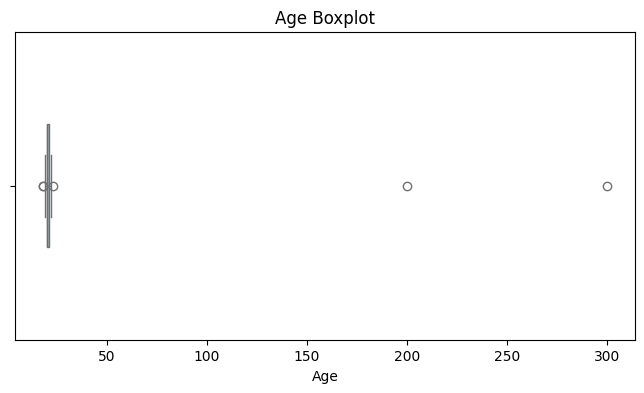

In [54]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Age',data=df,width=0.4,color='skyblue')
plt.title('Age Boxplot')
plt.show()

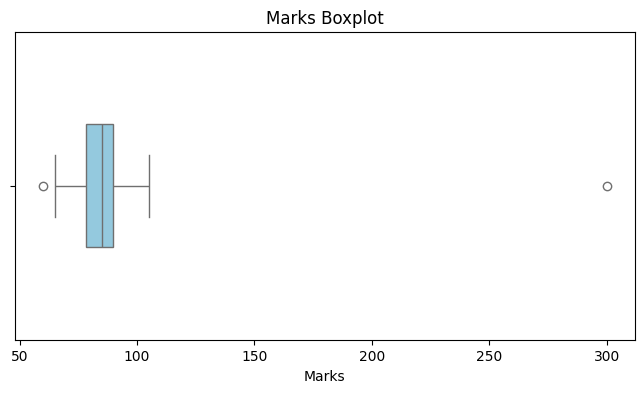

In [55]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Marks',data=df,width=0.4,color='skyblue')
plt.title('Marks Boxplot')
plt.show()

#### Identifying Outliers Using IQR Method

+ After visualizing the data with box plots, 

+ I used the IQR (Interquartile Range) method to identify the exact outlier values. 
    
+ This method helps find values that fall outside the normal range of the data

In [56]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

In [57]:
IQR = Q3 - Q1

In [58]:
Lower_limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

- After calculating the lower and upper limits using the IQR method,
##### Check Lower_Limit Outliers
- I checked for records with Age values below the lower limit to identify potential outliers.

In [59]:
df[df['Age'] < Lower_limit]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
10,111,Arjun,18.0,Male,91.0,IT,2019-11-11
24,125,Varun,18.0,Female,85.0,CSE,2021-01-25


#### Check Upper_Limit  Outliers
- I checked for records with Age values above the upper limit to identify potential outliers.

In [60]:
df[df['Age'] > Upper_Limit]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
5,106,Anjali,200.0,Female,95.0,ECE,2019-06-13
16,117,Manoj,23.0,Male,85.0,IT,2019-05-17
29,130,Sindhu,300.0,Female,105.0,ECE,NaT


#### Handling Outliers in Age Column

- After reviewing the outlier records identified by the IQR method,
- I found that the age value of 18 is realistic for student data.
  
- Therefore, I retained these records in the dataset.
- However, the values 200 and 300 are not realistic ages for students and were treated as data entry errors.
- These records were removed from the dataset.


In [61]:
df = df[(df['Age'] != 200) & (df['Age'] != 300)]

In [62]:
df[df['Age'] > Upper_Limit]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
16,117,Manoj,23.0,Male,85.0,IT,2019-05-17


#### Reviewing Age Outliers

- The IQR method identified Age values of 18 and 23 as potential outliers.
- However, these values are realistic for student data and do not indicate any data quality issues. 
- Therefore, I decided to retain these records and only remove clearly unrealistic values such as 200 and 300.

#### Outlier Detection in Marks Column

- After handling the outliers in the Age column,
- I analyzed the Marks column to identify any extreme values. 
- I used summary statistics, box plots, and the IQR method to detect potential outliers.

In [63]:
df['Marks'].describe().reset_index()

,index,Marks
0,count,28.000000
1,mean,89.714286
2,std,42.124909
3,min,60.000000
4,25%,77.750000
5,50%,85.000000
6,75%,88.250000
7,max,300.000000


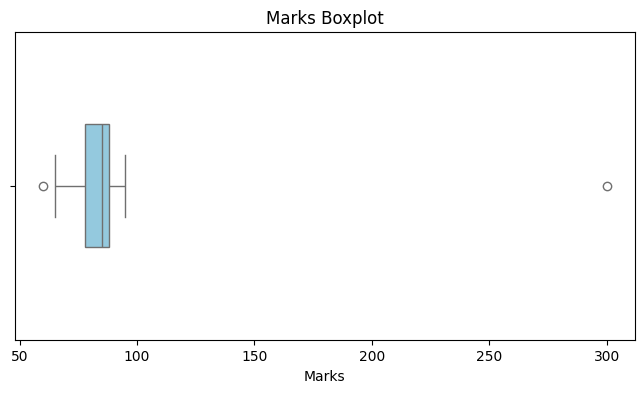

In [64]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Marks',data=df,width=0.4,color='skyblue')
plt.title('Marks Boxplot')
plt.show()

#### Identifying Outliers in Marks Column

- I used the IQR method to calculate the lower and upper limits for the Marks column and
  
- identify records that fall outside the acceptable range.

In [65]:
Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)

In [66]:
IQR = Q3 - Q1

In [67]:
Lower_limit = Q1 - 1.5 * IQR
Upper_limit = Q3 + 1.5 * IQR

In [68]:
print("Lower Limit:", Lower_limit)
print("Upper Limit:", Upper_limit)

Lower Limit: 62.0
Upper Limit: 104.0


#### Check Lower Outliers

In [69]:
df[df['Marks'] < Lower_limit]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
28,129,Tarun,19.0,Female,60.0,IT,2021-05-30


#### Check Upper Outliers

In [70]:
df[df['Marks'] > Upper_limit]

,Student_ID,Name,Age,Gender,Marks,Department,Join_Date
6,107,Ravi,21.0,Male,300.0,CSE,2022-07-07


#### Handling Outliers in Marks Column

- After analyzing the Marks column using the IQR method, 
- I found only one extreme value (300), which is not realistic for student marks.
  
- This value was treated as a data entry error and removed from the dataset.

In [71]:
df = df[df['Marks'] != 300]

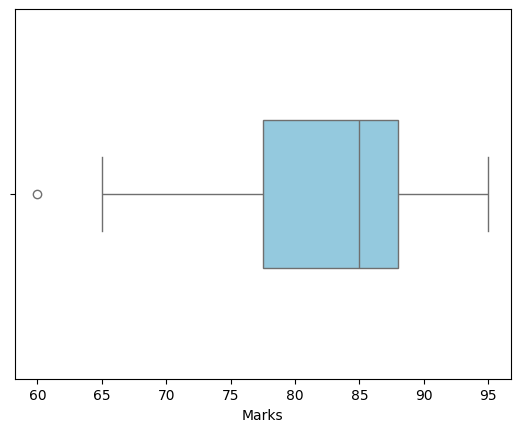

In [72]:
sns.boxplot(x=df['Marks'],width=0.4,color='skyblue')
plt.show()

#### Reviewing Marks Outliers

- After applying the IQR method, I found that the value 60 was also flagged as an outlier.
- But since it is a valid student mark, I kept it in the dataset. 
- Only clearly incorrect values were treated as outliers.


### Final Dataset Check

-  After completing data cleaning steps,

-  performed a final check on the dataset to ensure all issues such as missing values, duplicates, and outliers have been handled properly.
- The dataset is now consistent and ready for analysis.

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 0 to 28
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Student_ID  27 non-null     int64         
 1   Name        27 non-null     object        
 2   Age         27 non-null     float64       
 3   Gender      27 non-null     object        
 4   Marks       27 non-null     float64       
 5   Department  27 non-null     object        
 6   Join_Date   27 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 1.7+ KB


In [74]:
df.isnull().sum()

Student_ID    0
Name          0
Age           0
Gender        0
Marks         0
Department    0
Join_Date     0
dtype: int64

### Export Cleaned Data

In [75]:
df.to_csv("cleaned_student_data.csv", index=False)

#### Final Output

- The cleaned dataset was successfully exported to a CSV file. 
- The dataset is now free from missing values, duplicates, inconsistent formats, and major outliers.
- making it ready for further analysis or visualization.
